In [1]:
import wave
import numpy as np
import matplotlib.pyplot as plt
import os

file_path = "C:/Uner/Semester 5/Data Mining II/Coolyeah/archive/set_b"

datake = 1
file = os.listdir(file_path)[datake]
wav_file = wave.open(os.path.join(file_path,file), 'rb')

num_channels = wav_file.getnchannels()
sample_width = wav_file.getsampwidth()
frame_rate = wav_file.getframerate()  #Sample rate (samples per second)
num_frames = wav_file.getnframes()
duration = num_frames / float(frame_rate)  #dalam seconds

print(f"Channels: {num_channels}")
print(f"Sample Width: {sample_width} bytes")
print(f"Frame Rate: {frame_rate} Hz")
print(f"Number of Frames: {num_frames}")
print(f"Duration: {duration:.2f} seconds")

Channels: 1
Sample Width: 2 bytes
Frame Rate: 4000 Hz
Number of Frames: 87107
Duration: 21.78 seconds


In [2]:
33716/8.43

3999.525504151839

Audio Array: [ -73 -226 -151 ...  121  112  141]
Array Shape: (87107,)


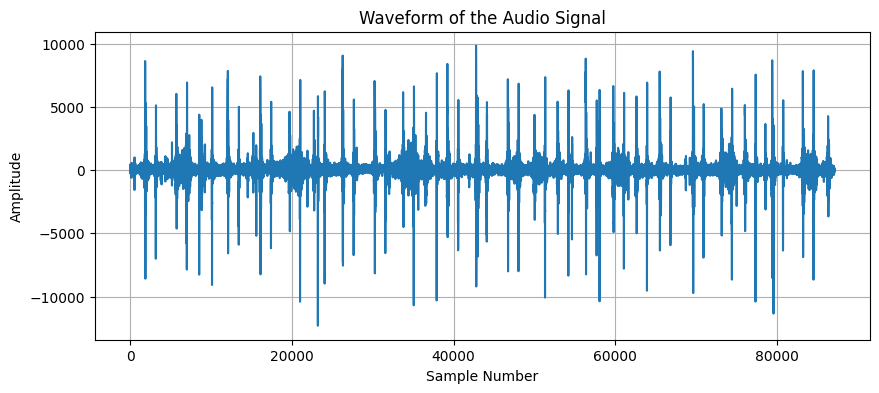

In [3]:
frames = wav_file.readframes(num_frames)
wav_file.close()                          

audio_data = np.frombuffer(frames, dtype=np.int16)

if num_channels > 1:
    audio_data = np.reshape(audio_data, (-1, num_channels))

print("Audio Array:", audio_data)
print("Array Shape:", audio_data.shape)

plt.figure(figsize=(10, 4))
if num_channels > 1:
    plt.plot(audio_data[:, 0])  
else:
    plt.plot(audio_data)        
plt.title('Waveform of the Audio Signal')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

In [4]:
from IPython.display import Audio
audio_to_play = audio_data[:,0] if num_channels > 1 else audio_data

Audio(audio_to_play, rate=frame_rate)

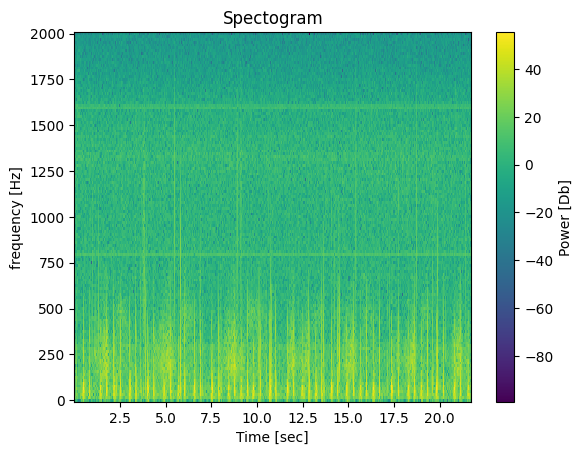

In [5]:
from scipy.signal import spectrogram

f,t, sxx = spectrogram(audio_data[:,0] if num_channels > 1 else audio_data, frame_rate)
plt.pcolormesh(t,f,10 * np.log10(sxx))
plt.ylabel('frequency [Hz]')
plt.xlabel("Time [sec]")
plt.title("Spectogram")
plt.colorbar(label = 'Power [Db]')
plt.show()

# --- 1. Ekstraksi Fitur dari Semua File Audio ---

In [6]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd

# Path ke direktori berisi file audio Anda
file_path = "C:/Uner/Semester 5/Data Mining II/Coolyeah/archive/set_b"

all_features = []
all_filenames = []

print("Memulai ekstraksi fitur dari file audio...")

# Loop melalui setiap file dalam direktori
for filename in os.listdir(file_path):
    if filename.endswith('.wav'):
        # Membentuk path lengkap ke file
        full_path = os.path.join(file_path, filename)
        
        try:
            # Memuat file audio menggunakan librosa
            # y = audio time series, sr = sample rate
            y, sr = librosa.load(full_path, sr=None)
            
            # Ekstraksi MFCC (misalnya, 20 koefisien)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
            
            # Mengambil rata-rata dari MFCC di seluruh frame waktu
            # Ini memberikan satu vektor fitur per file audio
            mfccs_mean = np.mean(mfccs.T, axis=0)
            
            all_features.append(mfccs_mean)
            all_filenames.append(filename)
        except Exception as e:
            print(f"Error memproses file {filename}: {e}")

print(f"Ekstraksi fitur selesai. Total {len(all_features)} file diproses.")

# Konversi list fitur menjadi NumPy array
X = np.array(all_features)

Memulai ekstraksi fitur dari file audio...
Ekstraksi fitur selesai. Total 656 file diproses.


# --- 2. Standardisasi Fitur ---

In [7]:
# Scaling fitur agar memiliki mean=0 dan variance=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nBentuk data fitur setelah scaling:", X_scaled.shape)


Bentuk data fitur setelah scaling: (656, 20)


# --- 3. Clustering dengan K-Means ---

In [8]:
# Tentukan jumlah cluster yang diinginkan (misalnya 3)
# Anda bisa bereksperimen dengan angka ini
num_clusters = 3 

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
# n_init=10 untuk menjalankan algoritma 10x dengan centroid awal berbeda

# Melakukan clustering dan mendapatkan label untuk setiap file
clusters = kmeans.fit_predict(X_scaled)

# --- 4. Menampilkan Hasil Clustering ---

In [9]:
results_df = pd.DataFrame({
    'filename': all_filenames,
    'cluster': clusters
})

# Mengurutkan berdasarkan cluster
results_df = results_df.sort_values(by='cluster')

print("\nHasil Clustering:")
print(results_df)

# Menampilkan jumlah file di setiap cluster
print("\nDistribusi file per cluster:")
print(results_df['cluster'].value_counts())


Hasil Clustering:
                                      filename  cluster
653            normal__298_1311685888900_B.wav        0
649           normal__294_1311681084248_D1.wav        0
19    Bunlabelledtest__115_1306259437619_D.wav        0
20    Bunlabelledtest__116_1306258689913_B.wav        0
22    Bunlabelledtest__118_1306262335509_A.wav        0
..                                         ...      ...
28    Bunlabelledtest__123_1306331925797_A.wav        2
25    Bunlabelledtest__121_1306263877235_B.wav        2
24   Bunlabelledtest__118_1306262335509_C2.wav        2
21   Bunlabelledtest__117_1306262456650_B1.wav        2
16    Bunlabelledtest__110_1305655332337_D.wav        2

[656 rows x 2 columns]

Distribusi file per cluster:
cluster
1    280
0    229
2    147
Name: count, dtype: int64


# --- 5. Visualisasi Hasil dengan PCA ---

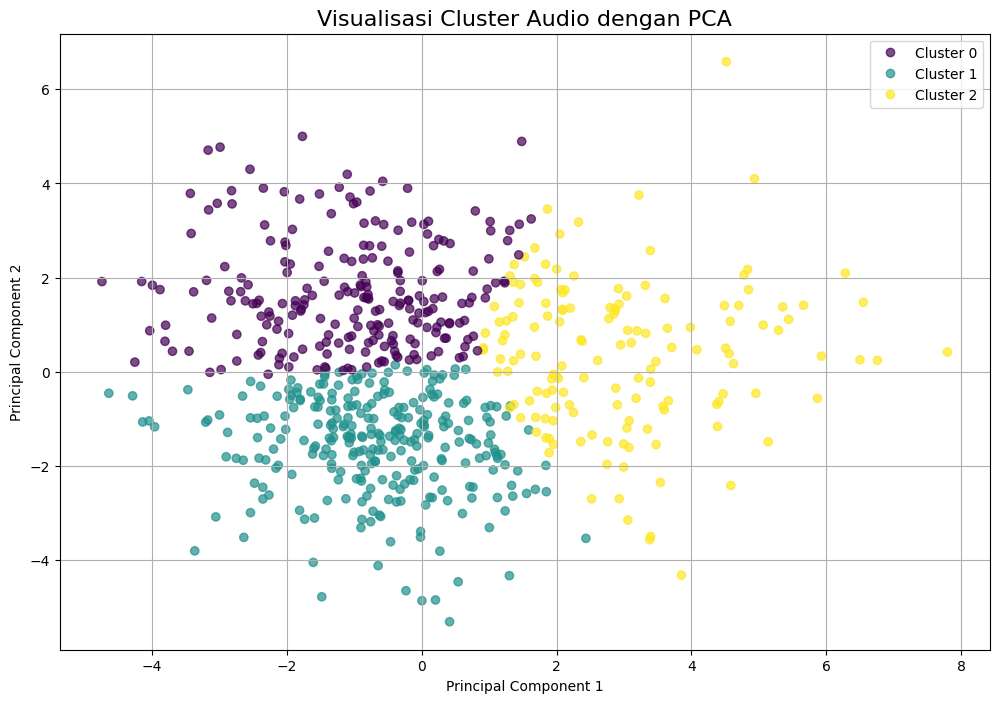

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)

plt.title('Visualisasi Cluster Audio dengan PCA', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(num_clusters)])
plt.show()